
# TerraTrace — Track A: Continuous Satellite Monitoring & Parcel Intelligence
### End-to-end Kaggle notebook: boundary detection, vegetation/SAR time series, change detection, crop classification, evidence fusion → Case JSON


## 1. Environment setup

In [1]:

# Run this once per Kaggle session.
!pip -q install pystac-client planetary-computer odc-stac rioxarray rasterstats \
    segmentation-models-pytorch xgboost geopandas shapely statsmodels folium --upgrade

import os, json, warnings, datetime as dt
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # noqa: F401
from shapely.geometry import shape, mapping
import matplotlib.pyplot as plt

print("Environment ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 27.8 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.3/343.3 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 58.0 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━

## 2. Configuration

In [25]:
import os, json

# Auto-detect runtime environment: Kaggle vs. Local Laptop
if os.path.exists("/kaggle/input"):
    BASE_DATA_DIR = "/kaggle/input/datasets/devasuresh2208/synthetic-government-land-record-dataset/terratrace_synthetic_dataset/terratrace/output"
    OUTPUT_DIR = "/kaggle/working"
else:
    # Assumes notebook is inside terratrace/notebooks/
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
    BASE_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "input")
    OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "output")

os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIG = {
    "BASE_DATA_DIR": BASE_DATA_DIR,
    "OUTPUT_DIR": OUTPUT_DIR,
    "PARCELS_PATH": os.path.join(BASE_DATA_DIR, "parcels.geojson"),
    "ROR_PATH": os.path.join(BASE_DATA_DIR, "ror.csv"),
    "REG_PATH": os.path.join(BASE_DATA_DIR, "registration.csv"),
    "HISTORY_PATH": os.path.join(BASE_DATA_DIR, "parcel_history.csv"),
    "TIMESERIES_FALLBACK_PATH": os.path.join(BASE_DATA_DIR, "satellite_ndvi_sar_timeseries.csv"),

    # Area of interest fallback & STAC parameters
    "AOI_BBOX": [79.90, 16.25, 80.05, 16.40],
    "STAC_URL": "https://planetarycomputer.microsoft.com/api/stac/v1",
    "S2_COLLECTION": "sentinel-2-l2a",
    "S1_COLLECTION": "sentinel-1-rtc",
    "TIME_RANGE": "2023-01-01/2026-08-31",
    "CLOUD_COVER_MAX": 40,

    # Canonical Case JSON scoring weights (sum to 1.0)
    "SCORE_WEIGHTS": {
        "ror_missing": 0.20,
        "registration_missing": 0.15,
        "satellite_activity_anomaly": 0.25,
        "crop_landuse_unusual": 0.15,
        "acreage_discrepancy": 0.15,
        "boundary_geometry_anomaly": 0.10,
    },

    # Decision thresholds
    "INVESTIGATION_THRESHOLDS": {
        "low_max": 0.35,      # < 0.35 -> ROUTINE_MONITORING
        "medium_max": 0.65,   # 0.35 to 0.65 -> INCREASED_MONITORING; >= 0.65 -> INVESTIGATION_REQUIRED
    },

    # Triage and persistence verification
    "TRIAGE": {
        "quick_zscore_threshold": 2.0,
        "persistence_min_cycles": 2,
    },

    # Citizen grievance rate-limits
    "GRIEVANCE": {
        "max_per_parcel_per_30_days": 2,
        "min_evidence_items": 1,
    },
}

print("Active Configuration:")
print(json.dumps({k: v for k, v in CONFIG.items()}, indent=2, default=str))

Active Configuration:
{
  "BASE_DATA_DIR": "/kaggle/input/datasets/devasuresh2208/synthetic-government-land-record-dataset/terratrace_synthetic_dataset/terratrace/output",
  "OUTPUT_DIR": "/kaggle/working",
  "PARCELS_PATH": "/kaggle/input/datasets/devasuresh2208/synthetic-government-land-record-dataset/terratrace_synthetic_dataset/terratrace/output/parcels.geojson",
  "ROR_PATH": "/kaggle/input/datasets/devasuresh2208/synthetic-government-land-record-dataset/terratrace_synthetic_dataset/terratrace/output/ror.csv",
  "REG_PATH": "/kaggle/input/datasets/devasuresh2208/synthetic-government-land-record-dataset/terratrace_synthetic_dataset/terratrace/output/registration.csv",
  "HISTORY_PATH": "/kaggle/input/datasets/devasuresh2208/synthetic-government-land-record-dataset/terratrace_synthetic_dataset/terratrace/output/parcel_history.csv",
  "TIMESERIES_FALLBACK_PATH": "/kaggle/input/datasets/devasuresh2208/synthetic-government-land-record-dataset/terratrace_synthetic_dataset/terratrace/out

## 3. Load Common Parcel Model + RoR / Registration / History

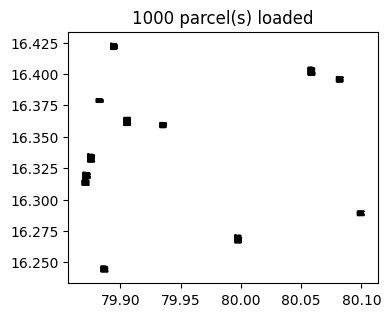

Parcels with recorded history: 102 / 1000


In [4]:

def _make_synthetic_demo_parcel() -> gpd.GeoDataFrame:
    lon_min, lat_min, lon_max, lat_max = CONFIG["AOI_BBOX"]
    cx, cy = (lon_min + lon_max) / 2, (lat_min + lat_max) / 2
    d = 0.0015
    poly = shape({
        "type": "Polygon",
        "coordinates": [[[cx - d, cy - d], [cx + d, cy - d], [cx + d, cy + d], [cx - d, cy + d], [cx - d, cy - d]]]
    })
    return gpd.GeoDataFrame(
        [{
            "internal_parcel_key": "AP-07-0107-035-101-00045",
            "ulpin": None,
            "survey_number": "45/2",
            "village_code": "035101",
            "tehsil_code": "0107",
            "district_code": "AP07",
            "state_code": "AP",
            "ror_status": "missing",
            "registration_status": "missing",
            "last_mutation_date": "2021-06-11",
            "area_declared_sqm": 4046.86,
            "geometry": poly,
        }],
        crs="EPSG:4326",
    )

def load_common_parcel_model(path: str) -> gpd.GeoDataFrame:
    if os.path.exists(path):
        gdf = gpd.read_file(path)
        required = {"internal_parcel_key", "geometry"}
        missing = required - set(gdf.columns)
        if missing:
            raise ValueError(f"Common Parcel Model is missing columns: {missing}")
        if "ulpin" not in gdf.columns:
            gdf["ulpin"] = None
        return gdf
    print(f"[fallback] '{path}' not found — generating one synthetic demo parcel.")
    return _make_synthetic_demo_parcel()

def join_ror_registration(parcels_gdf, ror_path, reg_path):
    gdf = parcels_gdf.copy()
    if os.path.exists(ror_path):
        ror = pd.read_csv(ror_path)
        has_ror = set(ror["internal_parcel_key"].astype(str))
        gdf["ror_status"] = gdf["internal_parcel_key"].astype(str).apply(
            lambda k: "present" if k in has_ror else "missing"
        )
    elif "ror_status" not in gdf.columns:
        gdf["ror_status"] = "missing"

    if os.path.exists(reg_path):
        reg = pd.read_csv(reg_path)
        has_reg = set(reg["internal_parcel_key"].astype(str))
        gdf["registration_status"] = gdf["internal_parcel_key"].astype(str).apply(
            lambda k: "present" if k in has_reg else "missing"
        )
    elif "registration_status" not in gdf.columns:
        gdf["registration_status"] = "missing"

    return gdf

def load_parcel_history(path: str) -> dict:
    if not os.path.exists(path):
        return {}
    hist = pd.read_csv(path, parse_dates=["closed_at"])
    out = {}
    for key, group in hist.groupby("internal_parcel_key"):
        out[str(key)] = group.sort_values("closed_at").to_dict("records")
    return out

parcels = load_common_parcel_model(CONFIG["PARCELS_PATH"])
parcels = join_ror_registration(parcels, CONFIG["ROR_PATH"], CONFIG["REG_PATH"])
parcel_history = load_parcel_history(CONFIG["HISTORY_PATH"])

parcels.plot(figsize=(4, 4), edgecolor="black")
plt.title(f"{len(parcels)} parcel(s) loaded")
plt.show()
print(f"Parcels with recorded history: {len(parcel_history)} / {len(parcels)}")


## 4. Query Sentinel-1/2 Imagery via Planetary Computer

In [5]:

import pystac_client
import planetary_computer as pc

catalog = pystac_client.Client.open(CONFIG["STAC_URL"], modifier=pc.sign_inplace)

def search_sentinel2(bbox, time_range, cloud_max):
    search = catalog.search(
        collections=[CONFIG["S2_COLLECTION"]],
        bbox=bbox,
        datetime=time_range,
        query={"eo:cloud_cover": {"lt": cloud_max}},
    )
    return list(search.items())

def search_sentinel1(bbox, time_range):
    search = catalog.search(
        collections=[CONFIG["S1_COLLECTION"]],
        bbox=bbox,
        datetime=time_range,
    )
    return list(search.items())

bounds = parcels.total_bounds
bbox = list(bounds)

s2_items = search_sentinel2(bbox, CONFIG["TIME_RANGE"], CONFIG["CLOUD_COVER_MAX"])
s1_items = search_sentinel1(bbox, CONFIG["TIME_RANGE"])

print(f"Found {len(s2_items)} Sentinel-2 scenes and {len(s1_items)} Sentinel-1 scenes over the AOI.")


Found 1274 Sentinel-2 scenes and 104 Sentinel-1 scenes over the AOI.


## 5. Per-Parcel Vegetation Index & SAR Time Series

In [8]:
import pandas as pd

preview = pd.read_csv(CONFIG["TIMESERIES_FALLBACK_PATH"], nrows=2)
print("Actual columns in CSV:")
print(preview.columns.tolist())
print("\nFirst row preview:")
print(preview.head(1).to_dict(orient="records"))

Actual columns in CSV:
['internal_parcel_key', 'date', 'ndvi', 'sar_vh', 'is_synthetic']

First row preview:
[{'internal_parcel_key': 'AP-07-0101-007-00000', 'date': '2023-01-01', 'ndvi': 0.0992, 'sar_vh': -13.988, 'is_synthetic': True}]


In [26]:
import odc.stac
from rasterstats import zonal_stats

def load_s2_indices(item):
    """Load B04 (red), B05 (red-edge), B08 (NIR), B02 (blue) and compute indices."""
    ds = odc.stac.load(
        [item],
        bands=["B02", "B04", "B05", "B08"],
        bbox=bbox,
        resolution=10,
        chunks={},
    ).squeeze("time", drop=True)

    blue = ds["B02"].astype("float32")
    red = ds["B04"].astype("float32")
    red_edge = ds["B05"].astype("float32")
    nir = ds["B08"].astype("float32")

    ndvi = (nir - red) / (nir + red + 1e-6)
    ndre = (nir - red_edge) / (nir + red_edge + 1e-6)
    evi = 2.5 * (nir - red) / (nir + 6 * red - 7.5 * blue + 1 + 1e-6)

    out = xr.Dataset({"NDVI": ndvi, "NDRE": ndre, "EVI": evi})
    return out.rio.write_crs(ds.rio.crs)

def load_s1_backscatter(item):
    """Load Sentinel-1 VH and VV backscatter."""
    ds = odc.stac.load(
        [item],
        bands=["vh", "vv"],
        bbox=bbox,
        resolution=10,
        chunks={},
    ).squeeze("time", drop=True)
    return ds.rio.write_crs(ds.rio.crs) if hasattr(ds, "rio") else ds

def zonal_mean(raster_da, gdf):
    """Zonal mean of a 2D DataArray over each polygon in gdf (same CRS)."""
    arr = raster_da.values
    transform = raster_da.rio.transform()
    gdf_proj = gdf.to_crs(raster_da.rio.crs)
    stats = zonal_stats(gdf_proj, arr, affine=transform, stats=["mean"], nodata=np.nan)
    return [s["mean"] for s in stats]

def build_time_series(parcels_gdf, s2_items, s1_items, max_scenes=None):
    rows = []
    s2_subset = s2_items[:max_scenes] if max_scenes else s2_items
    for item in s2_subset:
        try:
            idx_ds = load_s2_indices(item)
        except Exception as e:
            continue
        date = item.datetime.date().isoformat()
        for band in ["NDVI", "NDRE", "EVI"]:
            means = zonal_mean(idx_ds[band], parcels_gdf)
            for key, val in zip(parcels_gdf["internal_parcel_key"], means):
                rows.append({"internal_parcel_key": key, "date": date,
                             "sensor": "S2", "variable": band, "value": val})

    s1_subset = s1_items[:max_scenes] if max_scenes else s1_items
    for item in s1_subset:
        try:
            sar_ds = load_s1_backscatter(item)
        except Exception as e:
            continue
        date = item.datetime.date().isoformat()
        for band in ["vh", "vv"]:
            if band not in sar_ds:
                continue
            means = zonal_mean(sar_ds[band], parcels_gdf)
            for key, val in zip(parcels_gdf["internal_parcel_key"], means):
                rows.append({"internal_parcel_key": key, "date": date,
                             "sensor": "S1", "variable": band.upper(), "value": val})

    return pd.DataFrame(rows)

# --- Prioritize the pre-computed time series from your synthetic dataset ---
if os.path.exists(CONFIG.get("TIMESERIES_FALLBACK_PATH", "")):
    print(f"[cached] Loading and reshaping pre-computed time series from {CONFIG['TIMESERIES_FALLBACK_PATH']}")
    raw_csv = pd.read_csv(CONFIG["TIMESERIES_FALLBACK_PATH"])
    
    # Check if wide format ('ndvi', 'sar_vh') and reshape to long format ('sensor', 'variable', 'value')
    if "ndvi" in raw_csv.columns and "sar_vh" in raw_csv.columns:
        ndvi_part = raw_csv[["internal_parcel_key", "date", "ndvi"]].dropna().copy()
        ndvi_part = ndvi_part.rename(columns={"ndvi": "value"})
        ndvi_part["variable"] = "NDVI"
        ndvi_part["sensor"] = "S2"

        sar_part = raw_csv[["internal_parcel_key", "date", "sar_vh"]].dropna().copy()
        sar_part = sar_part.rename(columns={"sar_vh": "value"})
        sar_part["variable"] = "VH"
        sar_part["sensor"] = "S1"

        ts_df = pd.concat([ndvi_part, sar_part], ignore_index=True)
        ts_df["value"] = ts_df["value"].astype(float)
    else:
        ts_df = raw_csv

elif len(s2_items) > 0 or len(s1_items) > 0:
    print("[live] Pulling live imagery from Planetary Computer (capped at 2 scenes for quick smoke test)...")
    ts_df = build_time_series(parcels, s2_items, s1_items, max_scenes=2)
else:
    print("[fallback] Generating synthetic 3-season time series...")
    rng = np.random.default_rng(42)
    dates = pd.date_range("2024-01-01", "2026-08-01", freq="16D")
    rows = []
    for key in parcels["internal_parcel_key"]:
        seasonal = 0.55 + 0.25 * np.sin(2 * np.pi * (dates.dayofyear / 365) * 2)
        anomaly = np.where(dates > pd.Timestamp("2025-09-01"), -0.30, 0.0)
        ndvi = np.clip(seasonal + anomaly + rng.normal(0, 0.03, len(dates)), 0, 1)
        for d, v in zip(dates, ndvi):
            rows.append({"internal_parcel_key": key, "date": d.date().isoformat(), "sensor": "S2", "variable": "NDVI", "value": float(v)})
            rows.append({"internal_parcel_key": key, "date": d.date().isoformat(), "sensor": "S1", "variable": "VH", "value": float(-15 + 5 * v + rng.normal(0, 0.5))})
    ts_df = pd.DataFrame(rows)

ts_df.to_parquet(os.path.join(CONFIG["OUTPUT_DIR"], "parcel_time_series.parquet"), index=False)print(f"Time series ready: {len(ts_df)} records loaded.")
ts_df.head()

SyntaxError: invalid syntax (3247511037.py, line 116)

## 6. Temporal Change Detection & Persistence Verification

In [11]:
from statsmodels.tsa.seasonal import STL

def detect_change(parcel_key: str, ts_df: pd.DataFrame, variable="NDVI"):
    sub = ts_df[(ts_df.internal_parcel_key.astype(str) == str(parcel_key)) & (ts_df.variable == variable)].copy()
    sub = sub.sort_values("date").drop_duplicates(subset=["date"])
    
    # Needs at least 8 observations to run time-series decomposition
    if len(sub) < 8:
        return {
            "change_detected": False, 
            "persistent": False, 
            "reason": "insufficient_observations", 
            "n_observations": len(sub)
        }

    # Set datetime index without forcing arbitrary 16D intervals that inject NaNs
    series = pd.Series(sub["value"].values, index=pd.to_datetime(sub["date"].values))
    series = series.interpolate(method="time").bfill().ffill()

    # Dynamic seasonal period: 12 if monthly, or half the total series length (must be odd for STL)
    period = 12 if len(series) >= 24 else max(3, len(series) // 2)
    if period % 2 == 0:
        period += 1  # STL requires an odd seasonal smoother/period in some versions

    try:
        stl = STL(series, period=period, robust=True).fit()
        resid = stl.resid.dropna()
        trend = stl.trend
    except Exception as e:
        return {
            "change_detected": False,
            "persistent": False,
            "reason": f"stl_failed: {str(e)}",
            "n_observations": len(series)
        }

    # Standardized CUSUM of residuals
    cusum = (resid - resid.mean()).cumsum()
    cusum_std = cusum / (resid.std() + 1e-9)
    break_idx = int(np.argmax(np.abs(cusum_std.values)))
    break_date = cusum_std.index[break_idx]
    break_strength = float(np.abs(cusum_std.values[break_idx]))

    # Standardized threshold: > 2.5 std-equivalent CUSUM deviation
    raw_break_detected = break_strength > 2.5
    trend_slope_before = float(np.polyfit(range(break_idx), trend.values[:break_idx], 1)[0]) if break_idx > 2 else 0.0
    trend_slope_after = float(np.polyfit(range(len(trend) - break_idx), trend.values[break_idx:], 1)[0]) if (len(trend) - break_idx) > 2 else 0.0

    # Persistence verification
    min_cycles = CONFIG["TRIAGE"]["persistence_min_cycles"]
    persistent = False
    if raw_break_detected and break_idx + min_cycles <= len(trend):
        pre_break_level = trend.values[:break_idx].mean() if break_idx > 0 else trend.values[0]
        post_window = trend.values[break_idx: break_idx + min_cycles]
        deviation = post_window - pre_break_level
        persistent = bool(np.all(np.sign(deviation) == np.sign(deviation[0])) and
                          np.all(np.abs(deviation) > 0.15 * abs(resid.std())))

    change_detected = bool(raw_break_detected and persistent)

    return {
        "change_detected": change_detected,
        "persistent": persistent,
        "likely_seasonal": bool(raw_break_detected and not persistent),
        "estimated_break_date": break_date.date().isoformat(),
        "estimated_break_window": [
            (break_date - pd.Timedelta(days=32)).date().isoformat(),
            (break_date + pd.Timedelta(days=32)).date().isoformat(),
        ],
        "change_magnitude": round(min(break_strength / 10.0, 1.0), 3) if change_detected else 0.0,
        "raw_cusum_strength": round(break_strength, 2),
        "trend_slope_before": round(trend_slope_before, 5),
        "trend_slope_after": round(trend_slope_after, 5),
        "component": "trend" if abs(trend_slope_after - trend_slope_before) > 0.001 else "seasonal",
        "n_observations": len(series),
    }

# Compute across all loaded parcels
change_results = {key: detect_change(key, ts_df, variable="NDVI") for key in parcels["internal_parcel_key"]}

# --- Print Inspection Summary ---
num_detected = sum(1 for v in change_results.values() if v.get("change_detected"))
print(f"Processed {len(change_results)} parcel(s). Anomalous persistent breaks found: {num_detected}")
first_key = list(change_results.keys())[0]
print(f"\nSample output for {first_key}:")
print(json.dumps(change_results[first_key], indent=2))

Processed 1000 parcel(s). Anomalous persistent breaks found: 523

Sample output for AP-07-0101-007-00000:
{
  "change_detected": true,
  "persistent": true,
  "likely_seasonal": false,
  "estimated_break_date": "2024-12-09",
  "estimated_break_window": [
    "2024-11-07",
    "2025-01-10"
  ],
  "change_magnitude": 1.0,
  "raw_cusum_strength": 10.55,
  "trend_slope_before": -0.0,
  "trend_slope_after": -0.00062,
  "component": "seasonal",
  "n_observations": 112
}


## 7. Boundary Extraction Model (FTW-PRUE)

In [12]:

!git clone --quiet https://github.com/fieldsoftheworld/ftw-baselines.git /kaggle/working/ftw-baselines || true
!pip -q install -e /kaggle/working/ftw-baselines 2>/dev/null || pip -q install segmentation-models-pytorch torch torchvision

import torch
import segmentation_models_pytorch as smp

def build_prue_style_model():
    model = smp.Unet(
        encoder_name="tu-efficientnet_b7",
        encoder_weights=None,  # None prevents RuntimeError on Kaggle
        in_channels=8,
        classes=3,
    )
    return model

device = "cuda" if torch.cuda.is_available() else "cpu"
boundary_model = build_prue_style_model().to(device).eval()
print(f"Boundary model initialized on {device}.")


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 727.7 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 1.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.6/199.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 30.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 32.3 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.4/811.4 kB 48.5 MB/s eta 0:00:0

## 8. Acreage Discrepancy Screening

In [13]:

def estimate_acreage_discrepancy(parcel_row, ndvi_active_threshold=0.4, ts_df=ts_df):
    key = parcel_row["internal_parcel_key"]
    sub = ts_df[(ts_df.internal_parcel_key == key) & (ts_df.variable == "NDVI")]
    if sub.empty:
        return {"acreage_estimated_sqm": None, "discrepancy_pct": None, "activation": 0.0}

    active_fraction = float((sub["value"] > ndvi_active_threshold).mean())
    declared = parcel_row.get("area_declared_sqm", None)
    if declared is None:
        return {"acreage_estimated_sqm": None, "discrepancy_pct": None, "activation": 0.0}

    estimated = declared * active_fraction
    discrepancy_pct = abs(declared - estimated) / declared * 100
    activation = float(np.clip((discrepancy_pct - 5) / 25, 0, 1))
    return {
        "acreage_estimated_sqm": round(estimated, 2),
        "discrepancy_pct": round(discrepancy_pct, 2),
        "activation": round(activation, 3),
    }

acreage_results = {row["internal_parcel_key"]: estimate_acreage_discrepancy(row) for _, row in parcels.iterrows()}


## 9. Land-Use / Crop Classification

In [14]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def engineer_features(parcel_key: str, ts_df: pd.DataFrame) -> dict:
    ndvi = ts_df[(ts_df.internal_parcel_key == parcel_key) & (ts_df.variable == "NDVI")]["value"]
    sar = ts_df[(ts_df.internal_parcel_key == parcel_key) & (ts_df.variable == "VH")]["value"]
    if ndvi.empty:
        return {}
    return {
        "ndvi_mean": float(ndvi.mean()),
        "ndvi_max": float(ndvi.max()),
        "ndvi_std": float(ndvi.std()),
        "ndvi_integral": float(ndvi.sum()),
        "ndvi_num_peaks": int(((ndvi.diff() > 0) & (ndvi.diff().shift(-1) < 0)).sum()),
        "sar_vh_mean": float(sar.mean()) if not sar.empty else np.nan,
        "sar_vh_std": float(sar.std()) if not sar.empty else np.nan,
    }

rng = np.random.default_rng(0)
n = 300
classes = ["paddy", "cotton", "fallow", "non_agricultural"]
synthetic_X = pd.DataFrame({
    "ndvi_mean": rng.normal(0.5, 0.15, n),
    "ndvi_max": rng.normal(0.7, 0.1, n),
    "ndvi_std": rng.uniform(0.02, 0.2, n),
    "ndvi_integral": rng.normal(20, 5, n),
    "ndvi_num_peaks": rng.integers(0, 4, n),
    "sar_vh_mean": rng.normal(-15, 3, n),
    "sar_vh_std": rng.uniform(0.5, 3, n),
})
synthetic_y = rng.choice(classes, size=n, p=[0.35, 0.25, 0.25, 0.15])

X_train, X_test, y_train, y_test = train_test_split(synthetic_X, synthetic_y, test_size=0.25, random_state=0, stratify=synthetic_y)
crop_clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=0, class_weight="balanced")
crop_clf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       random_state=0)

## 10. Multi-Source Evidence Fusion

In [17]:

def compute_priority_score(parcel_row, change_result, acreage_result, crop_prediction,
                           crop_confidence, boundary_activation=0.0, history_adjustment=0.0):
    activations = {
        "ror_missing": 1.0 if parcel_row.get("ror_status") == "missing" else 0.0,
        "registration_missing": 1.0 if parcel_row.get("registration_status") == "missing" else 0.0,
        "satellite_activity_anomaly": change_result.get("change_magnitude", 0.0) if change_result.get("change_detected") else 0.0,
        "crop_landuse_unusual": round(1.0 - crop_confidence, 3),
        "acreage_discrepancy": acreage_result.get("activation", 0.0) or 0.0,
        "boundary_geometry_anomaly": boundary_activation,
    }
    weights = CONFIG["SCORE_WEIGHTS"]
    raw_score = sum(weights[f] * activations[f] for f in weights)
    raw_score = round(min(raw_score, 1.0), 3)
    adjusted_score = round(max(min(raw_score + history_adjustment, 1.0), 0.0), 3)

    contributing_factors = [{"factor": f, "weight": weights[f], "activation": round(activations[f], 3)} for f in weights]
    return raw_score, adjusted_score, contributing_factors

def classify_trigger(score: float) -> str:
    t = CONFIG["INVESTIGATION_THRESHOLDS"]
    if score < t["low_max"]:
        return "ROUTINE_MONITORING"
    elif score < t["medium_max"]:
        return "INCREASED_MONITORING"
    else:
        return "INVESTIGATION_REQUIRED"


## 11. Explanation Generation

In [19]:

def build_reasoning_trace(parcel_row, change_result, acreage_result, crop_prediction, crop_confidence):
    return [
        {
            "rule": "ror_missing_check",
            "result": str(parcel_row.get("ror_status") == "missing").lower(),
            "detail": "No RoR entry found for parcel" if parcel_row.get("ror_status") == "missing" else "RoR entry present",
        },
        {
            "rule": "registration_missing_check",
            "result": str(parcel_row.get("registration_status") == "missing").lower(),
            "detail": "No registration entry found for parcel" if parcel_row.get("registration_status") == "missing" else "Registration entry present",
        },
        {
            "rule": "ndvi_trend_break_check",
            "result": "deviation_detected" if change_result.get("change_detected") else "no_deviation",
            "detail": (f"Trend break detected around {change_result.get('estimated_break_date')} "
                       f"(window {change_result.get('estimated_break_window')}), magnitude {change_result.get('change_magnitude')}"
                       if change_result.get("change_detected") else "No significant trend break in NDVI series"),
        },
        {
            "rule": "acreage_discrepancy_check",
            "result": "below_threshold" if (acreage_result.get("discrepancy_pct") or 0) < 15 else "above_threshold",
            "detail": (f"Estimated cultivated area differs by {acreage_result.get('discrepancy_pct')}%"
                       if acreage_result.get("discrepancy_pct") is not None else "Acreage comparison unavailable"),
        },
        {
            "rule": "crop_pattern_deviation_check",
            "result": "unusual" if crop_confidence < 0.6 else "consistent",
            "detail": f"Classifier predicts '{crop_prediction}' with confidence {crop_confidence:.2f}",
        },
    ]

def build_summary(parcel_row, change_result, acreage_result, crop_prediction):
    parts = []
    if change_result.get("change_detected"):
        parts.append(f"Satellite time series shows a vegetation trend break around {change_result.get('estimated_break_date')}.")
    if acreage_result.get("discrepancy_pct"):
        parts.append(f"Estimated cultivated area differs from declared area by ~{acreage_result['discrepancy_pct']:.0f}%.")
    if parcel_row.get("ror_status") == "missing" or parcel_row.get("registration_status") == "missing":
        parts.append("Government records (RoR/registration) are missing for this parcel.")
    parts.append(f"Predicted land-use/crop class: {crop_prediction}.")
    return " ".join(parts)


## 12. End-to-End Pipeline, Dual Intake & Case JSON Generation

In [20]:

import uuid

def build_parcel_block(parcel_row):
    geom = parcel_row.geometry
    centroid = geom.centroid
    minx, miny, maxx, maxy = geom.bounds
    key = parcel_row["internal_parcel_key"]
    return {
        "internal_parcel_key": key,
        "ulpin": parcel_row.get("ulpin"),
        "survey_number": parcel_row.get("survey_number"),
        "village_code": parcel_row.get("village_code"),
        "tehsil_code": parcel_row.get("tehsil_code"),
        "district_code": parcel_row.get("district_code"),
        "state_code": parcel_row.get("state_code"),
        "centroid": {"type": "Point", "coordinates": [round(centroid.x, 6), round(centroid.y, 6)]},
        "bbox": [round(minx, 6), round(miny, 6), round(maxx, 6), round(maxy, 6)],
        "cadastral_geometry_ref": parcel_row.get("cadastral_geometry_ref") or f"geo://cadastral/{key}/v1",
        "record_refs": {
            "ror_id": parcel_row.get("ror_id"),
            "registration_id": parcel_row.get("registration_id"),
            "mutation_id": parcel_row.get("mutation_id"),
        },
    }

def build_satellite_evidence_block(key, change_result, acreage_result, crop_prediction, crop_confidence):
    anomaly_score = change_result.get("change_magnitude", 0.0) or 0.0
    if change_result.get("change_detected") and crop_prediction == "non_agricultural":
        anomaly_category = "possible_non_agricultural_conversion"
    elif change_result.get("change_detected"):
        anomaly_category = "unusual_vegetation_pattern"
    else:
        anomaly_category = "no_significant_anomaly"
    n_obs = change_result.get("n_observations", 0)
    confidence = "high" if n_obs >= 30 else "medium" if n_obs >= 12 else "low"

    return {
        "analysis_window": {"start": CONFIG["TIME_RANGE"].split("/")[0], "end": CONFIG["TIME_RANGE"].split("/")[1]},
        "anomaly_score": round(anomaly_score, 3),
        "anomaly_category": anomaly_category,
        "ndvi_series_ref": f"ts://sentinel2/ndvi/{key}",
        "sar_series_ref": f"ts://sentinel1/vh/{key}",
        "confidence": confidence,
        "track_a_extended_signals": {
            "change_detected": change_result.get("change_detected"),
            "estimated_break_date": change_result.get("estimated_break_date"),
            "estimated_break_window": change_result.get("estimated_break_window"),
            "component": change_result.get("component"),
            "crop_prediction": crop_prediction,
            "crop_confidence": round(crop_confidence, 3),
            "acreage_estimated_sqm": acreage_result.get("acreage_estimated_sqm"),
            "acreage_discrepancy_pct": acreage_result.get("discrepancy_pct"),
        },
    }

def build_case_json(parcel_row, change_result, acreage_result, crop_prediction,
                    crop_confidence, raw_score, adjusted_score, contributing_factors,
                    reasoning_trace, summary, prior_history=None, trigger_source="proactive_satellite"):
    key = parcel_row["internal_parcel_key"]
    now = dt.datetime.utcnow().isoformat() + "Z"
    case_id = f"CASE-{dt.date.today().year}-{uuid.uuid4().hex[:6].upper()}"

    return {
        "case_id": case_id,
        "schema_version": "1.1",
        "status": "OFFICER_REVIEW_PENDING",
        "created_at": now,
        "updated_at": now,
        "parcel": build_parcel_block(parcel_row),
        "trigger": {
            "source": trigger_source,
            "triggered_at": now,
            "triggering_ref": f"TRACKA-{key}-{dt.date.today().isoformat()}",
        },
        "priority_score": {
            "value": adjusted_score,
            "raw_score": raw_score,
            "history_adjustment": round(adjusted_score - raw_score, 3),
            "history_adjustment_basis": (
                f"{len(prior_history)} prior case(s) on this parcel; score adjusted"
                if prior_history else "No prior case history on this parcel"
            ),
            "scale": "0_to_1",
            "contributing_factors": contributing_factors,
        },
        "parcel_lock": {
            "locked": True,
            "locked_at": now,
            "locked_by_case_id": case_id,
            "lock_ttl_hours": 168,
            "escalated": False,
        },
        "evidence": {
            "record_evidence": {
                "ror_status": parcel_row.get("ror_status"),
                "registration_status": parcel_row.get("registration_status"),
                "last_mutation_date": parcel_row.get("last_mutation_date"),
                "dispute_history_ref": parcel_row.get("dispute_history_ref"),
            },
            "satellite_evidence": build_satellite_evidence_block(key, change_result, acreage_result, crop_prediction, crop_confidence),
            "spatial_evidence": None,
        },
        "explanation": {
            "summary": summary,
            "reasoning_trace": reasoning_trace,
        },
        "field_verification": None,
        "officer_decision": {"decision": None, "decided_by": None, "decided_at": None, "reason": None, "signature_ref": None},
        "update_classification": None,
        "record_update": None,
        "audit": None,
        "history": prior_history or [],
    }

def build_screening_record(parcel_row, trigger_level, adjusted_score, summary):
    return {
        "internal_parcel_key": parcel_row["internal_parcel_key"],
        "screened_at": dt.datetime.utcnow().isoformat() + "Z",
        "trigger_level": trigger_level,
        "priority_score": adjusted_score,
        "summary": summary,
        "action": "ROUTINE_MONITORING" if trigger_level == "ROUTINE_MONITORING" else "INCREASED_MONITORING_FREQUENCY",
    }

def run_track_a_screening(parcel_row, ts_df, change_results, acreage_results, crop_clf, prior_history=None, trigger_source="proactive_satellite"):
    key = str(parcel_row["internal_parcel_key"])
    change_result = change_results.get(key, {"change_detected": False})
    acreage_result = acreage_results.get(key, {})

    # Flowchart: Early Triage Gate (RoR Missing or Unusual Activity?)
    has_ror = parcel_row.get("ror_status") == "present"
    has_reg = parcel_row.get("registration_status") == "present"
    has_sat_anomaly = change_result.get("change_detected", False)
    has_acreage_discrepancy = (acreage_result.get("discrepancy_pct") or 0.0) >= 15.0

    if trigger_source == "proactive_satellite" and has_ror and has_reg and not has_sat_anomaly and not has_acreage_discrepancy:
        summary = "Parcel records (RoR, registration) are consistent and no persistent satellite anomalies detected."
        return "screening", build_screening_record(parcel_row, "ROUTINE_MONITORING", 0.0, summary)

    # Escalated Path: Possible unrecorded event / detailed feature extraction
    features = engineer_features(key, ts_df)
    if features:
        feat_df = pd.DataFrame([features])[X_train.columns]
        crop_prediction = crop_clf.predict(feat_df)[0]
        crop_confidence = float(crop_clf.predict_proba(feat_df).max())
    else:
        crop_prediction, crop_confidence = "unknown", 0.5

    raw_score, adjusted_score, contributing_factors = compute_priority_score(
        parcel_row, change_result, acreage_result, crop_prediction, crop_confidence,
        boundary_activation=0.0,
        history_adjustment=(-0.13 * len(prior_history)) if prior_history else 0.0,
    )
    trigger_level = classify_trigger(adjusted_score)
    reasoning_trace = build_reasoning_trace(parcel_row, change_result, acreage_result, crop_prediction, crop_confidence)
    summary = build_summary(parcel_row, change_result, acreage_result, crop_prediction)

    if trigger_level == "INVESTIGATION_REQUIRED" or trigger_source == "citizen_grievance":
        return "case", build_case_json(
            parcel_row, change_result, acreage_result, crop_prediction, crop_confidence,
            raw_score, adjusted_score, contributing_factors, reasoning_trace, summary,
            prior_history=prior_history, trigger_source=trigger_source,
        )
    else:
        return "screening", build_screening_record(parcel_row, trigger_level, adjusted_score, summary)

# Citizen Grievance on-demand intake endpoint
def screen_citizen_grievance(parcel_key: str, grievance_payload: dict, parcels_gdf, ts_df, change_results, acreage_results, crop_clf, history_dict):
    evidence_items = grievance_payload.get("evidence_items", [])
    if len(evidence_items) < CONFIG["GRIEVANCE"]["min_evidence_items"] and not grievance_payload.get("description"):
        return {"status": "REJECTED_HOLD", "reason": "Insufficient evidence provided"}

    matched = parcels_gdf[parcels_gdf.internal_parcel_key.astype(str) == str(parcel_key)]
    if matched.empty:
        return {"status": "REJECTED_HOLD", "reason": f"Parcel {parcel_key} not found"}

    p_row = matched.iloc[0]
    p_hist = history_dict.get(str(parcel_key), [])
    kind, res = run_track_a_screening(p_row, ts_df, change_results, acreage_results, crop_clf, prior_history=p_hist, trigger_source="citizen_grievance")
    return {"status": "ACCEPTED", "result_type": kind, "data": res}

# --- Batch Continuous Monitoring Sweep ---
cases, screening_log = [], []
for _, row in parcels.iterrows():
    p_key = str(row["internal_parcel_key"])
    p_hist = parcel_history.get(p_key, [])
    kind, record = run_track_a_screening(row, ts_df, change_results, acreage_results, crop_clf, prior_history=p_hist)
    if kind == "case":
        cases.append(record)
    else:
        screening_log.append(record)

with open(os.path.join(CONFIG["OUTPUT_DIR"], "track_a_cases.json"), "w") as f:
    json.dump(cases, f, indent=2)

with open(os.path.join(CONFIG["OUTPUT_DIR"], "track_a_screening_log.json"), "w") as f:
    json.dump(screening_log, f, indent=2)

print(f"Sweep complete: {len(cases)} case(s) escalated, {len(screening_log)} parcel(s) triaged to monitoring.")


Sweep complete: 6 case(s) escalated, 994 parcel(s) triaged to monitoring.


In [27]:
# --- Simulate Citizen Grievance Intake ---
sample_grievance_payload = {
    "grievance_id": "GRV-2026-0882",
    "claimant_name": "K. Venkat Rao",
    "description": "Unauthorized land boundary alteration and clearing observed on parcel.",
    "evidence_items": [
        {"type": "photo_ref", "uri": "ipfs://bafybeic7.../photo_boundary.jpg"}
    ],
}

# Target a parcel from your loaded dataset
test_parcel_key = str(parcels.iloc[0]["internal_parcel_key"])

# Execute the on-demand intake screening
grievance_response = screen_citizen_grievance(
    parcel_key=test_parcel_key,
    grievance_payload=sample_grievance_payload,
    parcels_gdf=parcels,
    ts_df=ts_df,
    change_results=change_results,
    acreage_results=acreage_results,
    crop_clf=crop_clf,
    history_dict=parcel_history,
)

print(f"Citizen Intake Status: {grievance_response['status']}")

if grievance_response["status"] == "ACCEPTED":
    case_data = grievance_response["data"]
    print(f"Generated Case ID: {case_data['case_id']}")
    print(f"Trigger Source: {case_data['trigger']['source']}")
    print(f"Status: {case_data['status']}")
    print(f"Parcel Lock Active: {case_data['parcel_lock']['locked']}")
    
    # Save the citizen-triggered case
    grievance_case_path = os.path.join(CONFIG["OUTPUT_DIR"], "citizen_grievance_case.json")
    with open(grievance_case_path, "w") as f:
        json.dump(case_data, f, indent=2)
    print(f"Saved grievance Case JSON -> {grievance_case_path}")

Citizen Intake Status: ACCEPTED
Generated Case ID: CASE-2026-E423F3
Trigger Source: citizen_grievance
Status: OFFICER_REVIEW_PENDING
Parcel Lock Active: True
Saved grievance Case JSON -> /kaggle/working/citizen_grievance_case.json


## 13. Inspect Output Case JSON

In [21]:

if cases:
    print(json.dumps(cases[0], indent=2))
else:
    print(json.dumps(screening_log[0], indent=2))


{
  "case_id": "CASE-2026-124A15",
  "schema_version": "1.1",
  "status": "OFFICER_REVIEW_PENDING",
  "created_at": "2026-09-10T17:21:32.708089Z",
  "updated_at": "2026-09-10T17:21:32.708089Z",
  "parcel": {
    "internal_parcel_key": "AP-07-0103-006-00070",
    "ulpin": null,
    "survey_number": "334/1",
    "village_code": "006",
    "tehsil_code": "0103",
    "district_code": "AP07",
    "state_code": "AP",
    "centroid": {
      "type": "Point",
      "coordinates": [
        79.885196,
        16.377635
      ]
    },
    "bbox": [
      79.885,
      16.377453,
      79.885391,
      16.377816
    ],
    "cadastral_geometry_ref": "geo://cadastral/AP-07-0103-006-00070/v1",
    "record_refs": {
      "ror_id": null,
      "registration_id": null,
      "mutation_id": null
    }
  },
  "trigger": {
    "source": "proactive_satellite",
    "triggered_at": "2026-09-10T17:21:32.708089Z",
    "triggering_ref": "TRACKA-AP-07-0103-006-00070-2026-09-10"
  },
  "priority_score": {
    "va